In [1]:
from pathlib import Path

import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
)

In [2]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [3]:
PROJECT_PATH = Path("/content/drive/MyDrive/UAH_Project")

VIDEO_FEATURE_PATH = (
    PROJECT_PATH
    / "datasets"
    / "processed"
    / "video_features_temporal"
)

SENSOR_DATASET_PATH = (
    PROJECT_PATH
    / "datasets"
    / "processed"
    / "uah_dataset.npz"
)

In [4]:
sensor = np.load(SENSOR_DATASET_PATH)

y = sensor["y"]
groups = sensor["groups"]

video_files = sorted(
    VIDEO_FEATURE_PATH.glob("*.npy")
)

print(len(video_files))

40


In [5]:
trip_embeddings = []
trip_labels = []

for trip_id, file in enumerate(video_files):

    data = np.load(file)

    # (num_windows,12,2048)
    frame_mean = data.mean(axis=1)

    # (2048,)
    trip_embedding = frame_mean.mean(axis=0)

    trip_embeddings.append(trip_embedding)

    trip_labels.append(
        y[groups == trip_id][0]
    )

trip_embeddings = np.stack(trip_embeddings)
trip_labels = np.array(trip_labels)

print(trip_embeddings.shape)
print(trip_labels.shape)

(40, 2048)
(40,)


In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    trip_embeddings,
    trip_labels,
    test_size=0.20,
    random_state=42,
    stratify=trip_labels,
)

print(X_train.shape)
print(X_test.shape)

print(y_train)
print(y_test)

(32, 2048)
(8, 2048)
[2 1 0 1 0 2 0 0 1 1 1 2 0 0 0 0 0 2 1 1 0 2 2 2 1 2 0 1 2 0 1 0]
[0 0 1 1 0 2 0 2]


In [7]:
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression(
    max_iter=5000,
    class_weight="balanced",
    random_state=42,
)

clf.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=5000, random_state=42)

In [8]:
y_pred = clf.predict(X_test)

In [9]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
)

print("Accuracy:", accuracy_score(y_test, y_pred))

print()

print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "NORMAL",
            "DROWSY",
            "AGGRESSIVE",
        ],
    )
)

Accuracy: 0.5

              precision    recall  f1-score   support

      NORMAL       0.50      0.50      0.50         4
      DROWSY       0.50      0.50      0.50         2
  AGGRESSIVE       0.50      0.50      0.50         2

    accuracy                           0.50         8
   macro avg       0.50      0.50      0.50         8
weighted avg       0.50      0.50      0.50         8



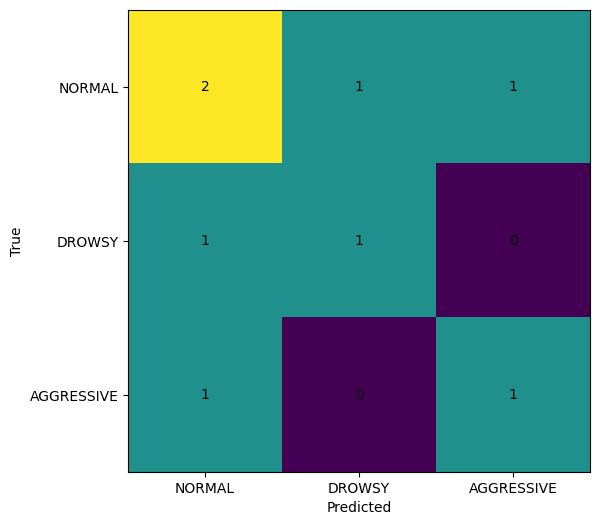

In [10]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,6))
plt.imshow(cm)

plt.xticks(
    [0,1,2],
    ["NORMAL","DROWSY","AGGRESSIVE"]
)

plt.yticks(
    [0,1,2],
    ["NORMAL","DROWSY","AGGRESSIVE"]
)

plt.xlabel("Predicted")
plt.ylabel("True")

for i in range(3):
    for j in range(3):
        plt.text(
            j,
            i,
            cm[i,j],
            ha="center",
            va="center",
        )

plt.show()

In [11]:
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

logo = LeaveOneGroupOut()
trip_ids = np.arange(len(trip_embeddings))  # her trip kendi grubu

preds, trues = [], []
for train_idx, test_idx in logo.split(trip_embeddings, trip_labels, groups=trip_ids):
    clf = LogisticRegression(max_iter=5000, class_weight="balanced",
                              random_state=42, C=0.01)  # güçlü regularization önemli
    clf.fit(trip_embeddings[train_idx], trip_labels[train_idx])
    preds.append(clf.predict(trip_embeddings[test_idx])[0])
    trues.append(trip_labels[test_idx][0])

print("LOTO Accuracy:", accuracy_score(trues, preds))

LOTO Accuracy: 0.375
